<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1829 | Val: 446 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[EfficientNet-B0] Epoch   1/100 | LR: 4.89e-04 | train loss 0.9168 acc 0.580 | val loss 0.6296 acc 0.731 *


[EfficientNet-B0] Epoch   2/100 | LR: 4.89e-04 | train loss 0.5459 acc 0.744 | val loss 0.4603 acc 0.800 *


[EfficientNet-B0] Epoch   3/100 | LR: 4.89e-04 | train loss 0.4733 acc 0.777 | val loss 0.4572 acc 0.834 *


[EfficientNet-B0] Epoch   4/100 | LR: 4.89e-04 | train loss 0.3791 acc 0.834 | val loss 0.4886 acc 0.796


...

[EfficientNet-B0] Epoch  23/100 | LR: 4.89e-08 | train loss 0.2306 acc 0.890 | val loss 0.3736 acc 0.879


[EfficientNet-B0] Epoch  24/100 | LR: 4.89e-08 | train loss 0.2252 acc 0.894 | val loss 0.3384 acc 0.874


[EfficientNet-B0] Epoch  25/100 | LR: 4.89e-09 | train loss 0.2122 acc 0.908 | val loss 0.3614 acc 0.863


[EfficientNet-B0] Epoch  26/100 | LR: 4.89e-09 | train loss 0.1917 acc 0.911 | val loss 0.3489 acc 0.877


[EfficientNet-B0] Epoch  27/100 | LR: 4.89e-09 | train loss 0.2154 acc 0.898 | val loss 0.3509 acc 0.874

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 27.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3338)


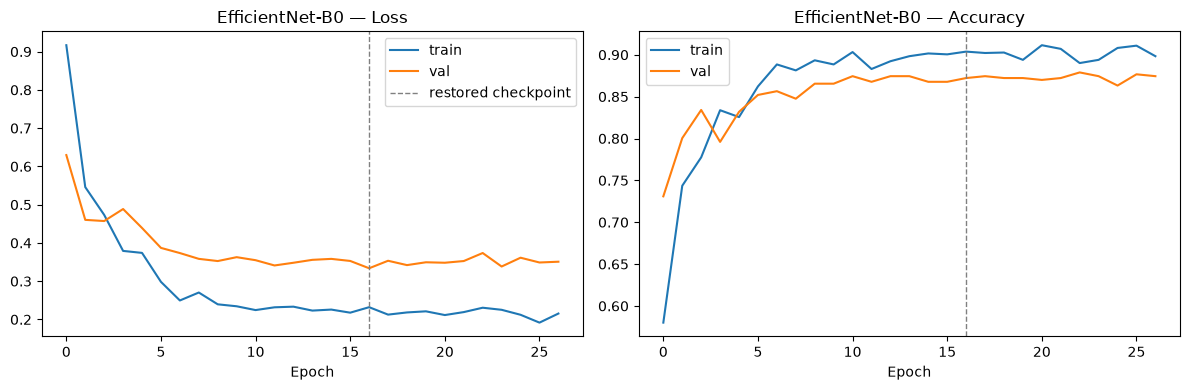

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.746


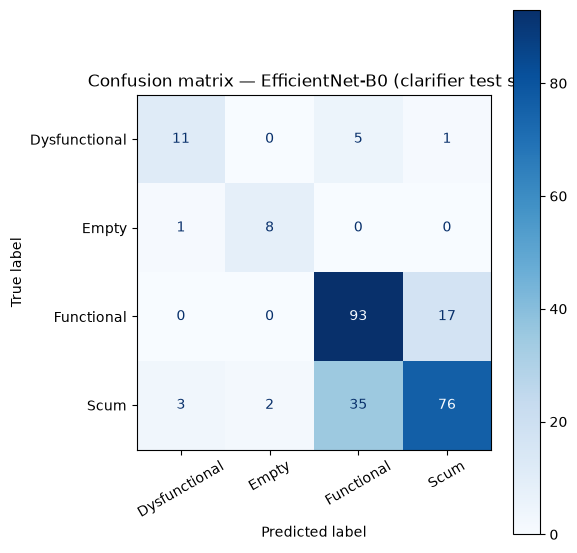

               precision    recall  f1-score   support

Dysfunctional      0.733     0.647     0.688        17
        Empty      0.800     0.889     0.842         9
   Functional      0.699     0.845     0.765       110
         Scum      0.809     0.655     0.724       116

     accuracy                          0.746       252
    macro avg      0.760     0.759     0.755       252
 weighted avg      0.755     0.746     0.744       252



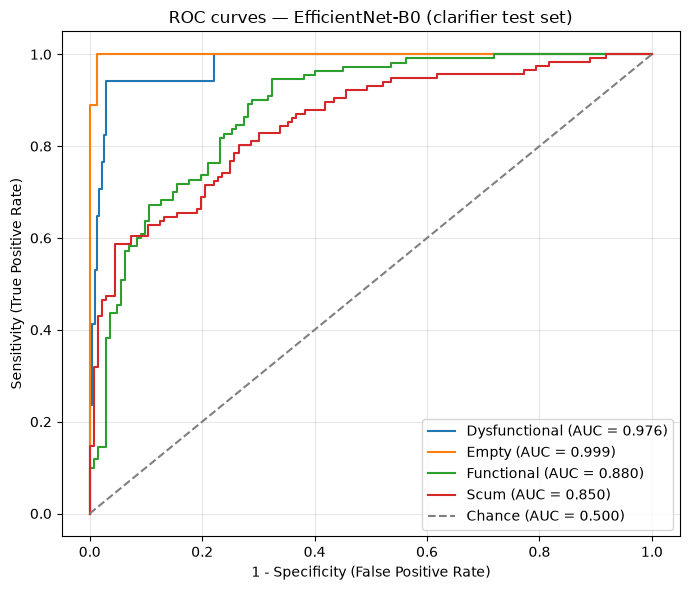

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.976
  Empty          : 0.999
  Functional     : 0.880
  Scum           : 0.850

Mean AUC (over 4/4 classes with test examples): 0.926


(np.float64(0.746031746031746),
 {'Dysfunctional': 0.9764705882352941,
  'Empty': 0.9986282578875171,
  'Functional': 0.8803457106274007,
  'Scum': 0.8504056795131847})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/clarifier_aug/results_clarifier_efficientnet_b0_Fisantekraal.pkl


Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
